<a href="https://colab.research.google.com/github/sarahbeatriz0205/projeto-final/blob/main/eda_insigths.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando o dataset

In [1]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
df = pd.read_csv(path + "/healthcare-dataset-stroke-data.csv")
display(df)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


## Correlação das variáveis

Variável irrelevante

In [19]:
from scipy.stats import chi2_contingency

df = df[df['gender'] != 'Other']
tabela_genero = pd.crosstab(df['gender'], df['stroke'])
print(tabela_genero)

chi2, p_valor, dof, expected = chi2_contingency(tabela_genero)

print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.5f}")

stroke     0    1
gender           
Female  2853  141
Male    2007  108
Estatística Qui-Quadrado: 0.3400
p-valor: 0.55983


In [27]:
tabela_hypertension = pd.crosstab(df['hypertension'], df['stroke'])
print(tabela_hypertension)

chi2, p_valor, dof, expected = chi2_contingency(tabela_hypertension)

print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.5f}")

stroke           0    1
hypertension           
0             4428  183
1              432   66
Estatística Qui-Quadrado: 81.5731
p-valor: 0.00000


In [28]:
print("Missing values in df:\n", df.isnull().sum())
print("\nNumber of duplicate rows in df:\n", df.duplicated().sum())

stroke            0    1
heart_disease           
0              4631  202
1               229   47
Estatística Qui-Quadrado: 90.2294
p-valor: 0.00000


In [29]:
# Matematicamente relevante, mas irrelevante para a análise

tabela_evermarried = pd.crosstab(df['ever_married'], df['stroke'])
print(tabela_evermarried)

chi2, p_valor, dof, expected = chi2_contingency(tabela_evermarried)

print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.5f}")

stroke           0    1
ever_married           
No            1727   29
Yes           3133  220
Estatística Qui-Quadrado: 58.8678
p-valor: 0.00000


In [31]:
# Matematicamente relevante, mas irrelevante para a análise

tabela_worktype = pd.crosstab(df['work_type'], df['stroke'])
print(tabela_worktype)

chi2, p_valor, dof, expected = chi2_contingency(tabela_worktype)

print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.5f}")

stroke            0    1
work_type               
Govt_job        624   33
Never_worked     22    0
Private        2775  149
Self-employed   754   65
children        685    2
Estatística Qui-Quadrado: 49.1591
p-valor: 0.00000


In [33]:
# Matematicamente relevante, mas irrelevante para a análise

tabela_Residence_type = pd.crosstab(df['Residence_type'], df['stroke'])
print(tabela_worktype)

chi2, p_valor, dof, expected = chi2_contingency(tabela_Residence_type)

print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.5f}")

stroke            0    1
work_type               
Govt_job        624   33
Never_worked     22    0
Private        2775  149
Self-employed   754   65
children        685    2
Estatística Qui-Quadrado: 1.0750
p-valor: 0.29983


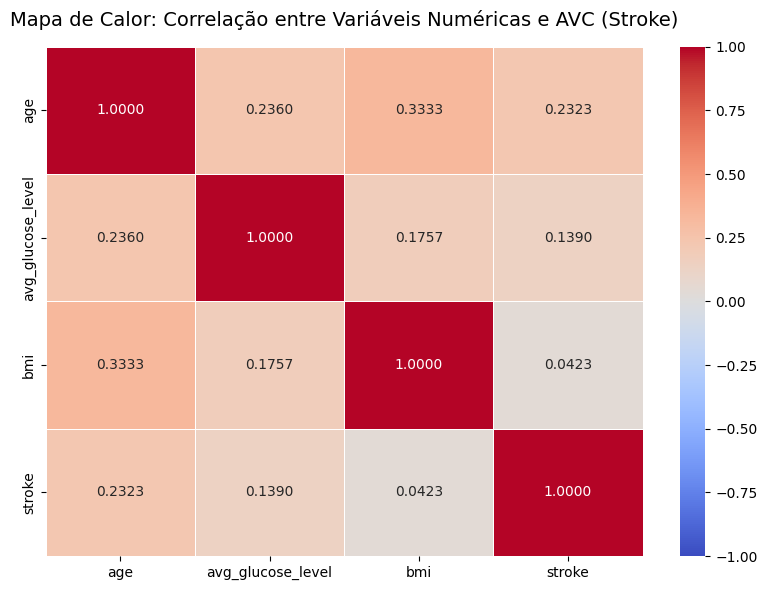

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_num = df[['age', 'avg_glucose_level', 'bmi', 'stroke']].dropna()
matriz_corr = df_num.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1, linewidths=0.5)

plt.title('Mapa de Calor: Correlação entre Variáveis Numéricas e AVC (Stroke)', fontsize=14, pad=15)
plt.tight_layout()

plt.show()

## Limpeza

Verificando se há valores ausentes

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


<Axes: >

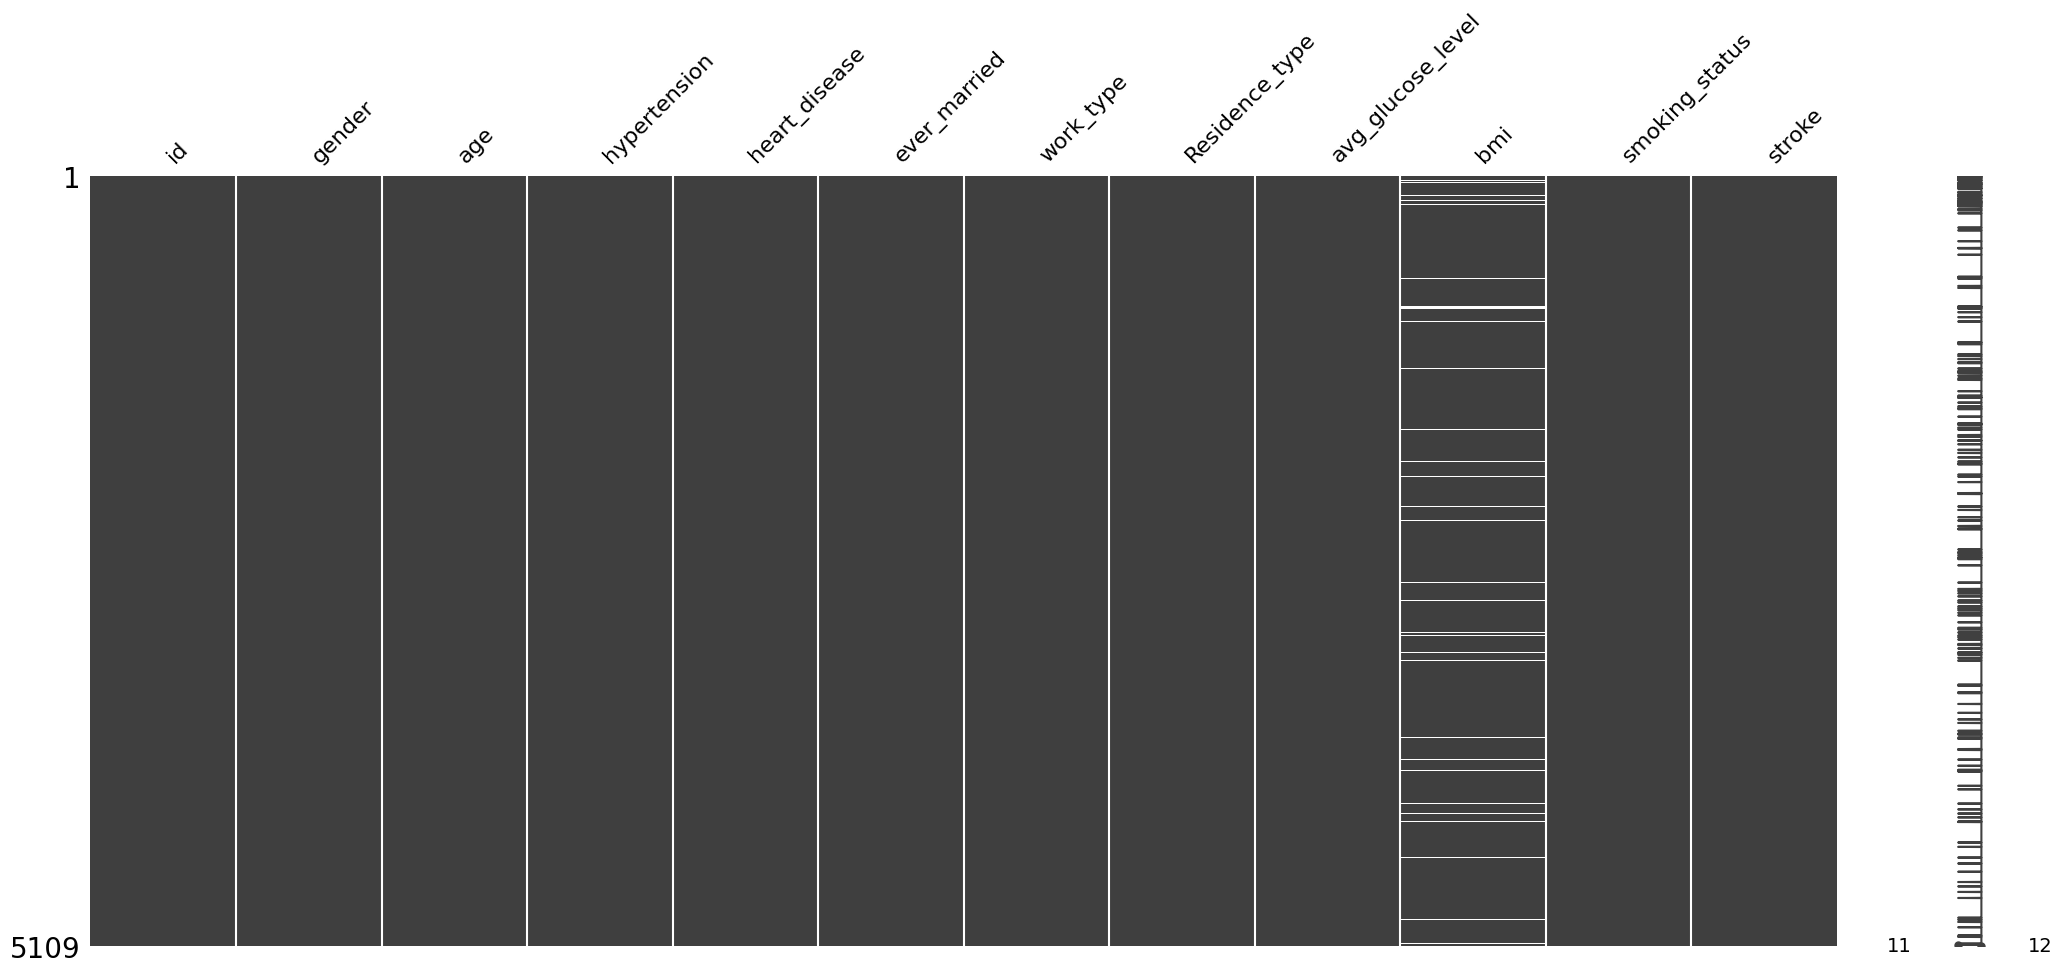

In [22]:
# Verificar valores ausentes
print(df.isna().sum())

# Visualização gráfica da matriz de ausência
import missingno as msno
msno.matrix(df)

Observei que apenas a coluna ['bmi'] possuía valores nulos, então substitui-os pela média

In [38]:
import numpy as np

media_bmi = df['bmi'].mean()
df['bmi'] = df['bmi'].replace(np.nan, media_bmi)
display(df['bmi'])

,bmi
0,36.60000
1,28.89456
2,32.50000
3,34.40000
4,24.00000
...,...
5105,28.89456
5106,40.00000
5107,30.60000
5108,25.60000


In [45]:
display(df.duplicated().sum())

df.drop_duplicates(subset=['id'],
                   keep='first',
                   inplace=True)

display(f"Registros após limpeza: {len(df)}")

np.int64(0)

'Registros após limpeza: 5109'

Categorizando idade, nível de glicose e índice de massa corpórea

In [40]:
# age
bins   = [0, 17, 29, 45, 65, 82]
labels = ['Jovem', 'Jovem-Adulto', 'Adulto', 'Adulto-Idoso', 'Idoso']

df['faixa_etaria'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=True
)

print(df[['gender', 'age', 'faixa_etaria']])

      gender   age  faixa_etaria
0       Male  67.0         Idoso
1     Female  61.0  Adulto-Idoso
2       Male  80.0         Idoso
3     Female  49.0  Adulto-Idoso
4     Female  79.0         Idoso
...      ...   ...           ...
5105  Female  80.0         Idoso
5106  Female  81.0         Idoso
5107  Female  35.0        Adulto
5108    Male  51.0  Adulto-Idoso
5109  Female  44.0        Adulto

[5109 rows x 3 columns]


In [41]:
# glicose
bins   = [55.12, 117.0, 154.0, 271.74]
labels = ['Normal', 'Pré-diabetes', 'Diabetes']

df['faixa_glicemica'] = pd.cut(
    df['avg_glucose_level'],
    bins=bins,
    labels=labels,
    right=True
)

print(df[['gender', 'avg_glucose_level', 'faixa_glicemica']])

      gender  avg_glucose_level faixa_glicemica
0       Male             228.69        Diabetes
1     Female             202.21        Diabetes
2       Male             105.92          Normal
3     Female             171.23        Diabetes
4     Female             174.12        Diabetes
...      ...                ...             ...
5105  Female              83.75          Normal
5106  Female             125.20    Pré-diabetes
5107  Female              82.99          Normal
5108    Male             166.29        Diabetes
5109  Female              85.28          Normal

[5109 rows x 3 columns]


In [42]:
# bmi
bins   = [10.3, 18.5, 24.9, 29.9, 34.9, 39.9, 97.6]
labels = ['Abaixo do peso', 'Peso normal', 'Sobrepeso', 'Obesidade Grau I', 'Obesidade Grau II', 'Obesidade Grau III']

df['faixa_bmi'] = pd.cut(
    df['bmi'],
    bins=bins,
    labels=labels,
    right=True
)

print(df[['gender', 'bmi', 'faixa_bmi']])

      gender       bmi           faixa_bmi
0       Male  36.60000   Obesidade Grau II
1     Female  28.89456           Sobrepeso
2       Male  32.50000    Obesidade Grau I
3     Female  34.40000    Obesidade Grau I
4     Female  24.00000         Peso normal
...      ...       ...                 ...
5105  Female  28.89456           Sobrepeso
5106  Female  40.00000  Obesidade Grau III
5107  Female  30.60000    Obesidade Grau I
5108    Male  25.60000           Sobrepeso
5109  Female  26.20000           Sobrepeso

[5109 rows x 3 columns]


Alterando variáveis "Unknown" para a que aparece mais na coluna "smoking_status"

In [43]:
df['smoking_status'].value_counts()

df['smoking_status'] = df['smoking_status'].replace("Unknown", "never smoked")
display(df['smoking_status'])

,smoking_status
0,formerly smoked
1,never smoked
2,never smoked
3,smokes
4,never smoked
...,...
5105,never smoked
5106,never smoked
5107,never smoked
5108,formerly smoked


## Dataset Final após a limpeza manual dos dados

In [46]:
display(df)
df.to_csv('dados_tratados.csv', index=False, encoding='utf-8')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,faixa_etaria,faixa_glicemica,faixa_bmi
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.60000,formerly smoked,1,Idoso,Diabetes,Obesidade Grau II
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.89456,never smoked,1,Adulto-Idoso,Diabetes,Sobrepeso
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.50000,never smoked,1,Idoso,Normal,Obesidade Grau I
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.40000,smokes,1,Adulto-Idoso,Diabetes,Obesidade Grau I
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.00000,never smoked,1,Idoso,Diabetes,Peso normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.89456,never smoked,0,Idoso,Normal,Sobrepeso
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.00000,never smoked,0,Idoso,Pré-diabetes,Obesidade Grau III
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.60000,never smoked,0,Adulto,Normal,Obesidade Grau I
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.60000,formerly smoked,0,Adulto-Idoso,Diabetes,Sobrepeso
